In [22]:
# ===============================================
# LIBRERÍAS
# ===============================================
from dotenv import load_dotenv
load_dotenv()

!pip install wikipedia

import os
import time
import requests
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
from urllib.parse import quote
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials
import matplotlib.pyplot as plt
import seaborn as sns
import wikipedia
import math




In [2]:
# ===============================================
# CONEXIÓN SPOTIFY
# ===============================================
client_id = os.getenv("SPOTIFY_CLIENT_ID")
client_secret = os.getenv("SPOTIFY_CLIENT_SECRET")

if not client_id or not client_secret:
    raise ValueError("⚠️ No se encontraron credenciales de Spotify en .env")
else:
    spotify_auth = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
    spotify = spotipy.Spotify(auth_manager=spotify_auth)
    print("✅ Conexión con Spotify lista")

✅ Conexión con Spotify lista


In [3]:
# ===============================================
# CONEXIÓN LAST.FM
# ===============================================
lastfm_api_key = os.getenv("API_KEY_LASTFM")
client_secret = os.getenv("SHARED_SECRET_LASTFM")

if not lastfm_api_key:
    raise ValueError("⚠️ No se encontró la API Key de Last.fm en .env")
else:
    url_test = f"http://ws.audioscrobbler.com/2.0/?method=artist.getinfo&artist=Coldplay&api_key={lastfm_api_key}&format=json"
    response = requests.get(url_test)

    if response.status_code == 200:
        print("✅ Conexión con Last.fm lista")
    else:
        raise ConnectionError(f"⚠️ Error al conectar con Last.fm: {response.status_code}")

✅ Conexión con Last.fm lista


In [27]:
# ===============================================
# CARGAR DATASET
# ===============================================
df = pd.read_csv("lollapalooza_2005_2025_final.csv")

print(df.head())
print(df.info())
print(df.describe(include='all'))

   Unnamed: 0                  festival_dates  year day_of_performance  \
0           1  July 31, 2025 - August 3, 2025  2025           Thursday   
1           2  July 31, 2025 - August 3, 2025  2025           Thursday   
2           3  July 31, 2025 - August 3, 2025  2025           Thursday   
3           4  July 31, 2025 - August 3, 2025  2025           Thursday   
4           5  July 31, 2025 - August 3, 2025  2025           Thursday   

               artist stage  headliner        genre              spotify_id  \
0  TYLER, THE CREATOR   NaN        1.0          NaN  4V8LLVI7PbaPR0K2TGSxFF   
1       GRACIE ABRAMS   NaN        NaN          NaN  4tuJ0bMpJh08umKkEXKUI5   
2          LUKE COMBS   NaN        1.0      country  718COspgdWOnwOFpJHRZHS   
3         ALEX WARREN   NaN        NaN          NaN  0fTSzq9jAh4c36UVb4V7CB   
4   CAGE THE ELEPHANT   NaN        NaN  modern rock  26T3LtbuGT1Fu9m0eRq5X3   

   spotify_popularity  
0                91.0  
1                89.0  
2       

In [28]:
# ===============================================
# EXPLORACIÓN DE DATOS
# ===============================================

print("\nNULOS POR COLUMNA")
print(df.isnull().sum())

print("\nPORCENTAJE DE NULOS")
print((df.isnull().sum() / len(df)) * 100)

print("\nCOLUMNAS")
print(df.columns)

print("\nDIMENSIONES DATASET")
print(df.shape)

print("\nVALORES ÚNICOS POR COLUMNA")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} valores únicos")

print("\nEJEMPLOS DE VALORES")
for col in df.columns:
    print(f"{col}: {df[col].unique()[:5]}")


NULOS POR COLUMNA
Unnamed: 0               0
festival_dates           0
year                     0
day_of_performance       0
artist                   1
stage                  174
headliner             2645
genre                 1414
spotify_id               1
spotify_popularity       1
dtype: int64

PORCENTAJE DE NULOS
Unnamed: 0             0.000000
festival_dates         0.000000
year                   0.000000
day_of_performance     0.000000
artist                 0.035199
stage                  6.124604
headliner             93.101021
genre                 49.771207
spotify_id             0.035199
spotify_popularity     0.035199
dtype: float64

COLUMNAS
Index(['Unnamed: 0', 'festival_dates', 'year', 'day_of_performance', 'artist',
       'stage', 'headliner', 'genre', 'spotify_id', 'spotify_popularity'],
      dtype='object')

DIMENSIONES DATASET
(2841, 10)

VALORES ÚNICOS POR COLUMNA
Unnamed: 0: 2841 valores únicos
festival_dates: 20 valores únicos
year: 20 valores únicos
day_of

In [29]:
# ===============================================
# LIMPIEZA INICIAL
# ===============================================

# asegurar que artist es string
df["headliner"] = df["headliner"].astype(str)

# eliminar columnas innecesarias

df = df.drop(columns=["spotify_id", "stage"], errors="ignore")

# verificar columnas restantes
print(df.columns)


# ===============================================
# CACHE PARA NO CONSULTAR ARTISTAS REPETIDOS
# ===============================================
genre_cache = {}

Index(['Unnamed: 0', 'festival_dates', 'year', 'day_of_performance', 'artist',
       'headliner', 'genre', 'spotify_popularity'],
      dtype='object')


In [30]:
# ===============================================
# FUNCIÓN SPOTIFY
# ===============================================
def get_genre_spotify(artist):

    if artist in genre_cache:
        return genre_cache[artist]

    try:
        result = spotify.search(q=f'artist:{artist}', type='artist', limit=1)

        items = result["artists"]["items"]

        if items:
            genres = items[0]["genres"]

            if genres:
                genre_cache[artist] = genres[0]
                return genres[0]

        return None

    except Exception as e:
        print(f"Spotify error con {artist}: {e}")
        return None

In [31]:
# ===============================================
# FUNCIÓN LASTFM
# ===============================================
def get_genre_lastfm(artist):

    try:

        url = f"http://ws.audioscrobbler.com/2.0/?method=artist.getinfo&artist={quote(artist)}&api_key={lastfm_api_key}&format=json"

        r = requests.get(url)
        data = r.json()

        bio = data.get("artist", {}).get("bio", {}).get("content", "")

        # buscar país dentro de la biografía
        possible_countries = [
            "United States","UK","England","Canada","Australia","France",
            "Germany","Spain","Brazil","Argentina","Mexico","Sweden",
            "Norway","Denmark","Italy","Netherlands","Japan","South Korea"
        ]

        for country in possible_countries:
            if country.lower() in bio.lower():
                return country

        return None

    except Exception as e:

        print(f"LastFM error con {artist}: {e}")
        return None

In [32]:
# ===============================================
# COMPLETAR GÉNEROS FALTANTES
# ===============================================

for i, row in df.iterrows():

    if pd.isna(row["genre"]):

        artist = row["headliner"]

        # intentar con spotify
        genre = get_genre_spotify(artist)

        # si no encuentra usar lastfm
        if genre is None:
            genre = get_genre_lastfm(artist)

        # guardar resultado
        df.at[i, "genre"] = genre

        time.sleep(0.2)  # evitar rate limit


print("\nProceso de enriquecimiento de géneros terminado")


Proceso de enriquecimiento de géneros terminado


In [33]:
# ===============================================
# RESULTADO FINAL
# ===============================================

print("\nNULOS DESPUÉS DEL PROCESO")
print(df["genre"].isnull().sum())

print("\nEJEMPLOS DE GÉNEROS")
print(df["genre"].value_counts().head(20))


NULOS DESPUÉS DEL PROCESO
0

EJEMPLOS DE GÉNEROS
genre
lo-fi house          1363
jangle pop             52
bedroom pop            30
indie                  29
indie rock             27
alternative r&b        21
edm                    18
country                17
modern rock            17
rap                    17
garage rock            14
melodic rap            13
indie folk             13
indie rock, indie      13
future bass            12
chamber pop            12
retro soul             12
alternative rock       11
k-pop                  11
surf rock              11
Name: count, dtype: int64


In [34]:
# ===============================================
# NORMALIZAR GÉNEROS
# ===============================================

def normalize_genre(genre):

    if pd.isna(genre):
        return "Unknown"

    genre = genre.lower()

    if "rock" in genre:
        return "Rock"

    if "indie" in genre or "alternative" in genre:
        return "Indie / Alternative"

    if "pop" in genre:
        return "Pop"

    if "hip hop" in genre or "rap" in genre or "trap" in genre:
        return "Hip-Hop / Rap"

    if "electronic" in genre or "house" in genre or "techno" in genre or "edm" in genre or "dance" in genre:
        return "Electronic"

    if "metal" in genre:
        return "Metal"

    if "punk" in genre:
        return "Punk"

    if "r&b" in genre or "soul" in genre:
        return "R&B / Soul"

    if "latin" in genre or "reggaeton" in genre:
        return "Latin"

    if "folk" in genre or "country" in genre:
        return "Folk / Country"

    return "Other"


df["genre_group"] = df["genre"].apply(normalize_genre)

print(df["genre_group"].value_counts())

genre_group
Electronic             1580
Rock                    357
Pop                     249
Other                   212
Indie / Alternative     184
Hip-Hop / Rap           138
Folk / Country           55
R&B / Soul               34
Punk                     22
Latin                     6
Metal                     4
Name: count, dtype: int64


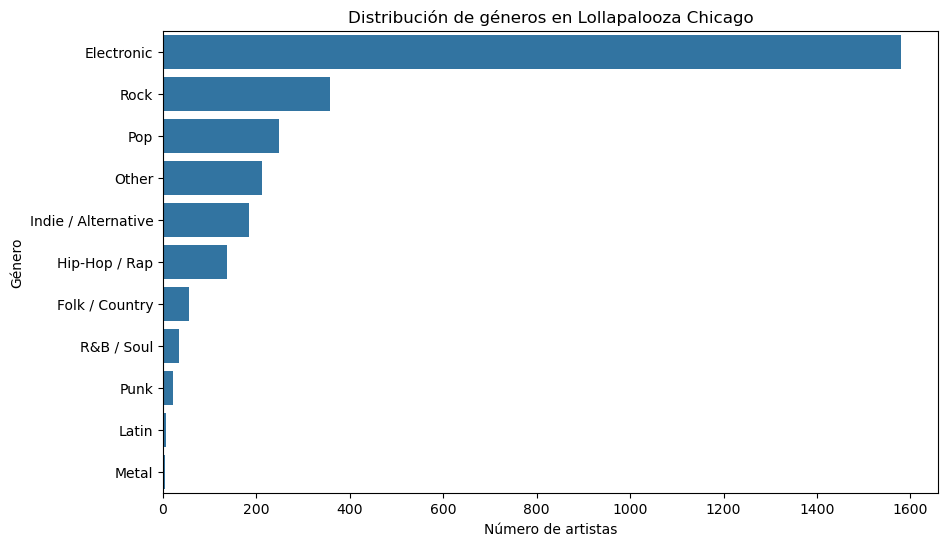

In [35]:
# ===============================================
# DISTRIBUCION DE GÉNEROS
# ===============================================
 
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="genre_group",
    order=df["genre_group"].value_counts().index
)

plt.title("Distribución de géneros en Lollapalooza Chicago")
plt.xlabel("Número de artistas")
plt.ylabel("Género")

plt.show()

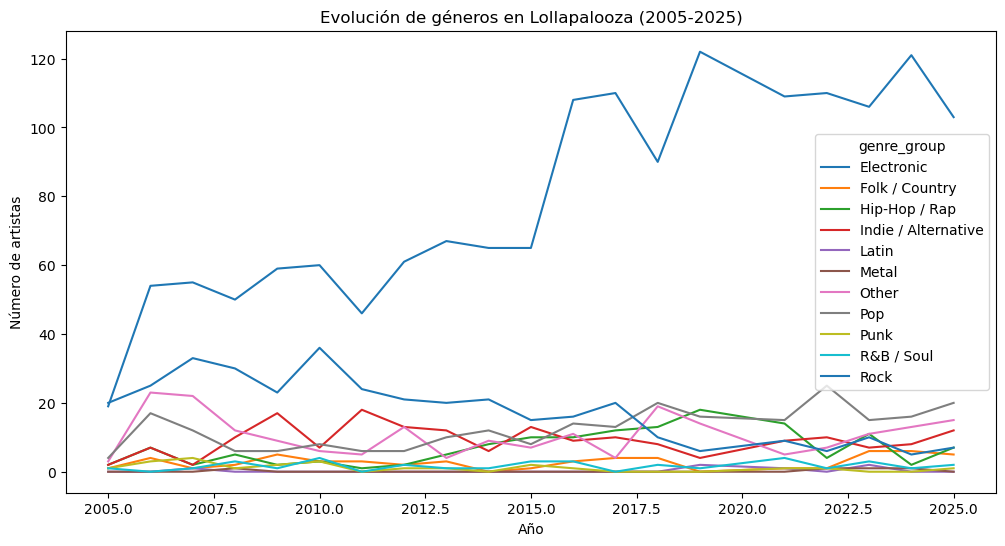

In [37]:
# ===============================================
# EVOLUCION DE GÉNEROS POR YEARS
# ===============================================
 
genre_year = df.groupby(["year","genre_group"]).size().reset_index(name="count")

pivot = genre_year.pivot(index="year", columns="genre_group", values="count").fillna(0)

pivot.plot(
    kind="line",
    figsize=(12,6)
)

plt.title("Evolución de géneros en Lollapalooza (2005-2025)")
plt.ylabel("Número de artistas")
plt.xlabel("Año")

plt.show()

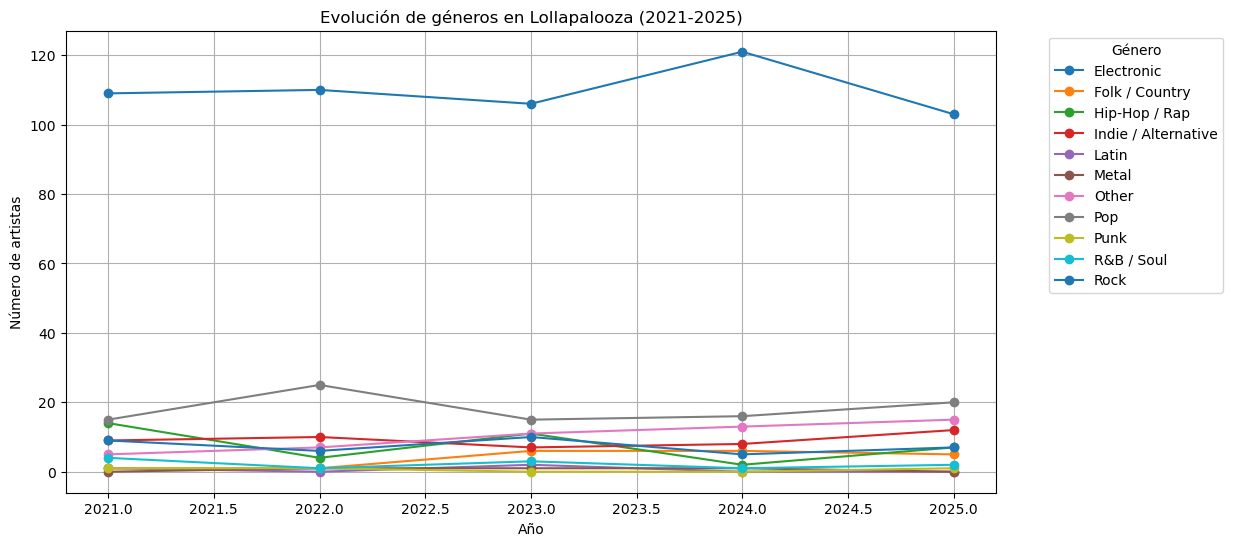

🎵 Géneros más frecuentes en los últimos 5 años:
genre_group
Electronic             549
Pop                     91
Other                   51
Indie / Alternative     46
Hip-Hop / Rap           38
Name: count, dtype: int64


In [38]:
# Filtrar últimos 5 años
last_5_years = df["year"].max() - 5
df_last5 = df[df["year"] > last_5_years]

# Agrupar por año y género
genre_year = df_last5.groupby(["year","genre_group"]).size().reset_index(name="count")

# Pivot para gráfica
pivot = genre_year.pivot(index="year", columns="genre_group", values="count").fillna(0)

# Gráfica
pivot.plot(
    kind="line",
    figsize=(12,6),
    marker='o'
)

plt.title(f"Evolución de géneros en Lollapalooza ({df_last5['year'].min()}-{df_last5['year'].max()})")
plt.ylabel("Número de artistas")
plt.xlabel("Año")
plt.grid(True)
plt.legend(title="Género", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Top géneros más frecuentes en los últimos 5 años
top_generos = df_last5['genre_group'].value_counts().head(5)
print("🎵 Géneros más frecuentes en los últimos 5 años:")
print(top_generos)

In [39]:
# Exportar
df.to_csv("lollapalooza_clean.csv", index=False)
print("✅ CSV exportado listo para Power BI: lollapalooza_clean.csv")

✅ CSV exportado listo para Power BI: lollapalooza_clean.csv
